### Урок 5. Домашняя работа

Есть два набора точек - *x_hw* и *y_hw*. В рамках домашней работы нужно
* визуализировать набор точек
* найти коэффициенты регрессии $w_0, w_1$ по шагам, как в уроке
* посчитать предсказание в виде $\hat{y} = w_0 + w_1x$ и визуализировать его вместе с точками *x_hw* и *y_hw*

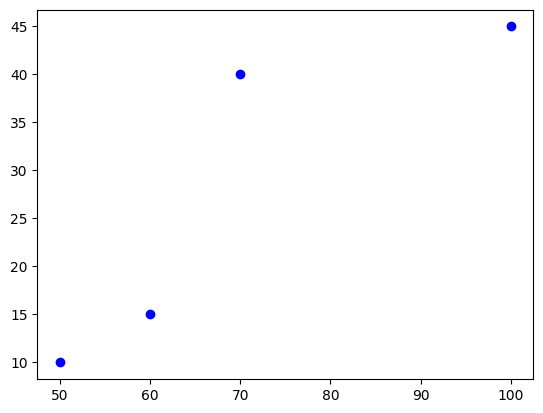

In [2]:
from matplotlib import pyplot as plt
from sympy import *
import numpy as np
%matplotlib inline
x_hw = [50, 60, 70, 100]
y_hw = [10, 15, 40, 45]

plt.scatter(x_hw, y_hw, marker='o', color='blue', label='HW')
plt.show()

In [3]:
X = np.array([[1,x_hw[0]], [1, x_hw[1]], [1, x_hw[2]], [1, x_hw[3]]])
Y = np.array([[y_hw[0]], [y_hw[1]], [y_hw[2]], [y_hw[3]]])
X

array([[  1,  50],
       [  1,  60],
       [  1,  70],
       [  1, 100]])

In [15]:
from numpy.linalg import inv
X_T_X = (X.T).dot(X)
X_T_X_inverted = inv(X_T_X)

X_T_X_inverted

array([[ 3.75000000e+00, -5.00000000e-02],
       [-5.00000000e-02,  7.14285714e-04]])

In [23]:
w = X_T_X_inverted.dot(X.T).dot(Y)

print("w_1=%.5f, w_2=%.3f" % (w[0][0],w[1][0]))

w_1=-22.50000, w_2=0.714


In [20]:
#second variant as mathematic module
X = Matrix([[1, x_hw[0]], [1, x_hw[1]], [1, x_hw[2]], [1, x_hw[3]]])
Y = Matrix(y_hw)

In [21]:
X_pseudo_inverse = (X.T * X)**(-1) * X.T
X_pseudo_inverse

Matrix([
[  5/4,    3/4, 1/4,  -5/4],
[-1/70, -1/140,   0, 3/140]])

In [22]:
w = X_pseudo_inverse * Y
w

Matrix([
[-45/2],
[  5/7]])

In [26]:
from matplotlib import pyplot as plt
import numpy as np

%matplotlib inline

# задаём границы координатных осей
margin = 10
X_min = 20
X_max = X[:,1].max()+margin

# набор точек, чтобы нарисовать прямую
X_support = np.linspace(X_min, X_max, num=100)
# предсказания нашей модели
Y_model = w[0][0] + w[1][0]*X_support

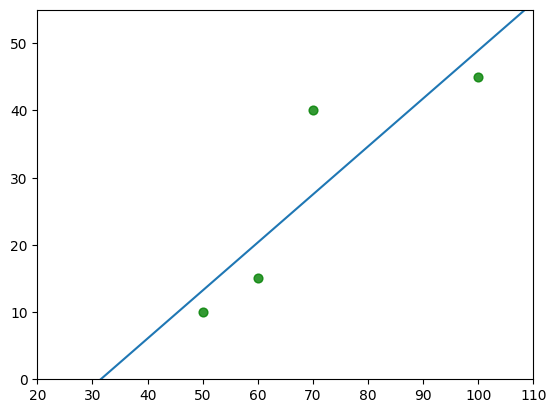

In [27]:
# настройка графика
plt.xlim(X_min, X_max)
plt.ylim(0, Y[:,0].max() + margin)
# рисуем исходные точки
plt.scatter(X[:,1], Y[:,0], 40, 'g', 'o', alpha=0.8)
# предсказания модели
plt.plot(X_support, Y_model)

plt.show()